In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import scienceplots
import seaborn as sns
from matplotlib.ticker import FuncFormatter

from qr.utils import *

sns.set_style("whitegrid")
plt.style.use(["science", "no-latex", "grid"])

In [2]:
ticker = "PFE"
df, df_emp = load_data(ticker)

In [3]:
with open(
    Path.home() / f"dev_cpp/qr/data/results/{ticker}/samples/registry.json",
    "r",
) as f:
    registry = json.load(f)

print(json.dumps(registry["9b4f4eeb64935be4"], indent=2))
df_sim = pl.read_parquet(
    Path.home() / f"dev_cpp/qr/data/results/{ticker}/samples/9b4f4eeb64935be4.parquet"
)
df_sim = preprocess_sim(df_sim)

{
  "config": {
    "ticker": "PFE",
    "duration_hours": 1000,
    "use_mixture": false,
    "use_total_lvl": false,
    "use_alpha": false,
    "compute_alpha_pnl": false,
    "impact": {
      "type": "no_impact"
    },
    "alpha": {
      "kappa": 0.1386,
      "sigma": 0.5,
      "scale": 0.55
    }
  },
  "seed_used": 3422894976,
  "timestamp": "2026-03-24T19:01:18"
}


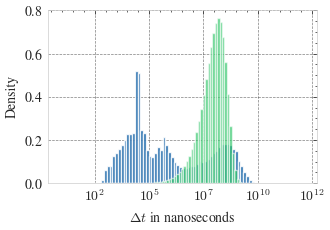

In [4]:
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    ax.hist(
        df["delta_t"].explode().log10(),
        bins=80,
        density=True,
        label="Empirical",
        alpha=0.85,
    )
    ax.hist(
        df_sim.filter(pl.col("dt") > 0)["dt"].log10(),
        bins=80,
        density=True,
        label="QR",
        alpha=0.6,
    )
    ax.set_xlabel(r"$\Delta t$ in nanoseconds")
    ax.set_ylabel("Density")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"$10^{{{int(x)}}}$"))
    fig.tight_layout()
    # fig.savefig("../paper/delta_t_exp_fit_PFE.pdf", bbox_inches="tight")
    plt.show()

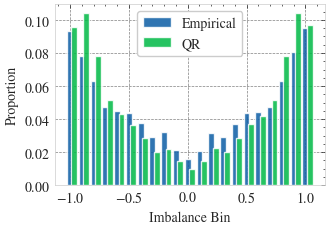

In [5]:
imb_dist = (
    df.filter(pl.col("event").eq("Trade"))
    .group_by("imbalance")
    .agg(pl.col("len").sum())
    .with_columns(proportion=pl.col("len") / pl.col("len").sum())
    .sort("imbalance")
)

imb_sim = (
    df_sim.filter(pl.col("event").eq("Trade"))["imbalance"]
    .value_counts(normalize=True)
    .sort("imbalance")
)


# with mpl.rc_context({"axes.facecolor": "white"}):
with transparent():
    fig, ax = plt.subplots(figsize=(3.5, 2.5))
    fig.patch.set_alpha(0)  # transparent figure background

    x = imb_dist["imbalance"]
    width = 0.05

    ax.bar(x, imb_dist["proportion"], width, label="Empirical", alpha=0.85)
    ax.bar(x + width * 3 / 4, imb_sim["proportion"], width, label="QR", alpha=0.85)

    ax.set_xlabel("Imbalance Bin")
    ax.set_ylabel("Proportion")
    ax.legend()
    ax.set_facecolor("white")  # white inside the axes
    ax.patch.set_facecolor("white")
    ax.patch.set_alpha(1)
    plt.tight_layout()
    # fig.savefig(
    #     "../../paper/imb_distrib_before_trade_PFE.pdf",
    #     bbox_inches="tight",
    # )
    plt.show()

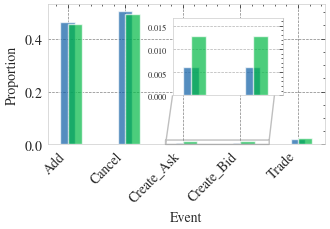

In [6]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

event_dist = (
    df.group_by("event")
    .agg(pl.col("len").sum())
    .with_columns(proportion=pl.col("len") / pl.col("len").sum())
    .sort("event")
)
event_dist_sim = df_sim["event"].value_counts(normalize=True).sort("event")

labels = event_dist["event"]
x = np.arange(len(labels))
width = 0.25

ax.bar(x, event_dist["proportion"], width, label="Empirical", alpha=0.7)
ax.bar(
    x + width / 2,
    event_dist_sim["proportion"],
    width,
    label="QR",
    alpha=0.7,
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_xlabel("Event")
ax.set_ylabel("Proportion")
# ax.legend()

# Zoom patch on Create_Bid / Create_Ask region
create_idx = [i for i, l in enumerate(labels) if "Create" in l]
x1 = min(create_idx) - 0.3
x2 = max(create_idx) + 0.5
y1 = 0
y2 = (
    max(
        max(event_dist["proportion"][i] for i in create_idx),
        max(event_dist_sim["proportion"][i] for i in create_idx),
    )
    * 1.3
)

axins = ax.inset_axes([0.45, 0.35, 0.4, 0.55])
axins.bar(
    x[create_idx],
    [event_dist["proportion"][i] for i in create_idx],
    width,
    alpha=0.7,
)
axins.bar(
    x[create_idx] + width / 2,
    [event_dist_sim["proportion"][i] for i in create_idx],
    width,
    alpha=0.7,
)
axins.set_xticks([])
# axins.set_xticklabels([labels[i] for i in create_idx], fontsize=6, rotation=45, ha="right")
axins.tick_params(labelsize=6)
axins.grid(True, alpha=0.3)
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

ax.indicate_inset_zoom(axins, edgecolor="grey", alpha=0.5)

plt.tight_layout()
# fig.savefig("../paper/emp_vs_qr_event_distrib_PFE.pdf", bbox_inches="tight")
plt.show()

In [7]:
bin_ns = int(5 * 60 * 1e9)  # 5 minutes in ns

returns_emp = (
    df_emp.with_columns((pl.col("ts_event").cast(pl.Int64) // bin_ns).alias("bin"))
    .group_by("date", "bin")
    .agg(pl.col("mid").last())
    .sort("date", "bin")
    .with_columns((pl.col("mid") - pl.col("mid").shift(1)).over("date").alias("ret_5m"))
    .drop_nulls("ret_5m")
)

returns_sim = (
    df_sim.with_columns((pl.col("ts_event") // bin_ns).alias("bin"))
    .group_by("date", "bin")
    .agg(pl.col("mid").last())
    .sort("date", "bin")
    .with_columns((pl.col("mid") - pl.col("mid").shift(1)).over("date").alias("ret_5m"))
    .drop_nulls("ret_5m")
)

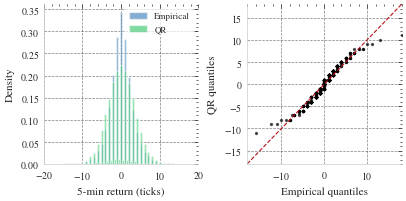

In [8]:
fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(4, 2), gridspec_kw={"width_ratios": [1, 1]}
)

# --- Histogram ---
bins = np.linspace(-20, 20, 80)

ax1.hist(
    returns_emp["ret_5m"],
    bins=bins,
    density=True,
    alpha=0.5,
    color="C0",
    label="Empirical",
)
ax1.hist(
    returns_sim["ret_5m"],
    bins=bins,
    density=True,
    alpha=0.5,
    color="C1",
    label="QR",
)

ax1.set_xlim(-20, 20)
ax1.set_xlabel("5-min return (ticks)", fontsize=8)
ax1.set_ylabel("Density", fontsize=8)
ax1.tick_params(labelsize=7)
ax1.legend(fontsize=6.5, framealpha=0.7, edgecolor="none")
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --- QQ plot ---
q = np.linspace(0.001, 0.999, 500)
emp_q = np.quantile(returns_emp["ret_5m"].to_numpy(), q)
sim_q = np.quantile(returns_sim["ret_5m"].to_numpy(), q)

ax2.scatter(emp_q, sim_q, s=2, color="black", alpha=0.6)
lim = max(abs(emp_q.min()), abs(emp_q.max()), abs(sim_q.min()), abs(sim_q.max()))
ax2.plot([-lim, lim], [-lim, lim], "--", lw=0.8, color="#B5121B")
ax2.set_xlim(-lim, lim)
ax2.set_ylim(-lim, lim)

ax2.set_xlabel("Empirical quantiles", fontsize=8)
ax2.set_ylabel("QR quantiles", fontsize=8)
ax2.tick_params(labelsize=7)
# ax2.legend(fontsize=6.5, framealpha=0.7, edgecolor="none")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.tight_layout(pad=0.3)
# fig.savefig("../../paper/returns_5m_PFE.pdf", bbox_inches="tight", dpi=300)
plt.show()

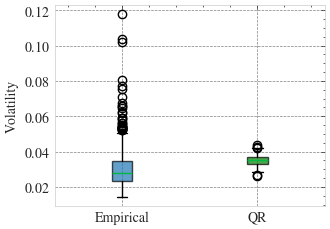

In [9]:
vol_emp = compute_volatility_sampled_empirical(df_emp)
vol_sim = compute_volatility_sampled_simulation(df_sim)

fig, ax = plt.subplots(figsize=(3.5, 2.5))

labels = ["Empirical", "QR"]
colors = ["tab:blue", "green"]

vol_data = [
    vol_emp["volatility_per_hour"].to_numpy(),
    vol_sim["volatility_per_hour"].to_numpy(),
]
bp = ax.boxplot(vol_data, tick_labels=labels, patch_artist=True)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel(r"Volatility")

plt.tight_layout()
# fig.savefig("../../paper/volatility_5m_PFE.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_3361581/1643267724.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([sz, sze], labels=labels, patch_artist=True)


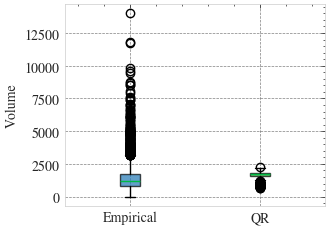

In [10]:
fig, ax = plt.subplots(figsize=(3.5, 2.5))

sz = (
    df_emp.filter(pl.col("event").eq("Trade"))
    .group_by(pl.col("date"), pl.col("ts_event").dt.hour())
    .agg(pl.col("size").sum())["size"]
)
sze = (
    df_sim.filter(pl.col("event").eq("Trade"))
    .group_by(pl.col("date"), pl.col("ts_event") // HOUR_NS)
    .agg(pl.col("size").sum())["size"]
    / 200
)

labels = ["Empirical", "QR"]
colors = ["tab:blue", "tab:green"]

bp = ax.boxplot([sz, sze], labels=labels, patch_artist=True)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel(r"Volume")


plt.tight_layout()
# fig.savefig("../../paper/hourly_traded_volume_PFE.pdf", bbox_inches="tight")
plt.show()

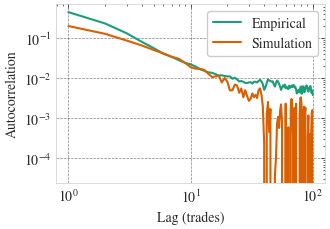

In [11]:
max_lag = 100
acf_emp = trade_sign_acf_empirical(df_emp, max_lag)
acf_sim = trade_sign_acf_simulation(df_sim, max_lag)

fig, ax = plt.subplots(figsize=(3.5, 2.5))
lags = np.arange(1, max_lag + 1)
ax.plot(lags, acf_emp[1:], lw=1.5, color="#1B9E77", label="Empirical")
ax.plot(lags, acf_sim[1:], lw=1.5, color="#D95F02", label="Simulation")
ax.set_xlabel("Lag (trades)")
ax.set_ylabel("Autocorrelation")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
# fig.savefig("../../paper/orderflow_acf_PFE.pdf", bbox_inches="tight")
plt.show()

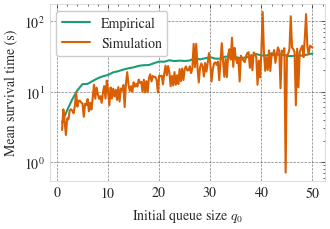

In [12]:
surv_emp = queue_survival_empirical(df_emp)
surv_sim = queue_survival_simulation(
    df_sim.with_columns(pl.col("q_1") / 200, pl.col("q_-1") / 200)
)

mean_emp = (
    surv_emp.group_by("q0")
    .agg(pl.col("survival_ns").mean() / 1e9)
    .sort("q0")
    .filter(pl.col("q0").is_between(1, 50))
)

mean_sim = (
    surv_sim.group_by("q0")
    .agg(pl.col("survival_ns").mean() / 1e9)
    .sort("q0")
    .filter(pl.col("q0").is_between(1, 50))
)

fig, ax = plt.subplots(figsize=(3.5, 2.5))
ax.plot(
    mean_emp["q0"], mean_emp["survival_ns"], lw=1.5, color="#1B9E77", label="Empirical"
)
ax.plot(
    mean_sim["q0"], mean_sim["survival_ns"], lw=1.5, color="#D95F02", label="Simulation"
)
ax.set_xlabel(r"Initial queue size $q_0$")
ax.set_ylabel("Mean survival time (s)")
ax.set_yscale("log")
ax.legend()
fig.tight_layout()
# fig.savefig("../../paper/queue_survival_PFE.pdf", bbox_inches="tight")
plt.show()

/tmp/ipykernel_3361581/1091752396.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([daily_emp, daily_sim], labels=["Empirical", "QR"], patch_artist=True)


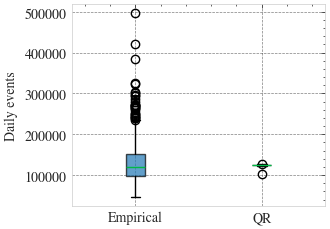

In [13]:
daily_emp = df_emp.group_by("date").len()["len"]
daily_sim = df_sim.group_by("date").len()["len"]

fig, ax = plt.subplots(figsize=(3.5, 2.5))
bp = ax.boxplot([daily_emp, daily_sim], labels=["Empirical", "QR"], patch_artist=True)
for patch, color in zip(bp["boxes"], ["tab:blue", "tab:green"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel("Daily events")
plt.tight_layout()
plt.show()